In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Data Loading

In [2]:
df = pd.read_csv("3_Summary of Weather.csv", low_memory=False)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (119040, 31)


,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,7/1/1942,1.016,NaN,25.555556,22.222222,23.888889,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,7/2/1942,0,NaN,28.888889,21.666667,25.555556,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,7/3/1942,2.54,NaN,26.111111,22.222222,24.444444,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,7/4/1942,2.54,NaN,26.666667,22.222222,24.444444,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,7/5/1942,0,NaN,26.666667,21.666667,24.444444,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Select only required columns

In [3]:
# Select only required columns
df = df[['MinTemp', 'MaxTemp']]
df

,MinTemp,MaxTemp
0,22.222222,25.555556
1,21.666667,28.888889
2,22.222222,26.111111
3,22.222222,26.666667
4,21.666667,26.666667
...,...,...
119035,18.333333,28.333333
119036,18.333333,29.444444
119037,18.333333,28.333333
119038,18.333333,28.333333


# Data Cleaning

In [4]:
# Count of missing values in EACH column
print(df.isnull().sum())

MinTemp    0
MaxTemp    0
dtype: int64


In [5]:
# Check Data types in columns
print(df.dtypes)

MinTemp    float64
MaxTemp    float64
dtype: object


In [6]:
# ── Check how many bad rows exist ────────────────────
bad_rows = df[df['MaxTemp'] < df['MinTemp']]

print("Number of rows where MaxTemp < MinTemp:", len(bad_rows))
print()
print("The bad rows:")
print(bad_rows[['MinTemp', 'MaxTemp']])

Number of rows where MaxTemp < MinTemp: 32

The bad rows:
         MinTemp    MaxTemp
28773  16.666667 -17.777778
28774  15.555556 -17.777778
28775  17.777778 -17.777778
28776  16.111111 -17.777778
28777  17.777778 -17.777778
28778  15.555556 -17.777778
28779  15.555556 -17.777778
28780  17.777778 -17.777778
43379  -1.666667  -6.111111
73630  18.888889 -17.777778
73631  16.666667 -17.777778
73632  16.111111 -17.777778
73633  16.666667 -17.777778
73634  22.777778 -17.777778
73635  22.777778 -17.777778
73636  21.111111 -17.777778
73637  18.888889 -17.777778
73638  16.666667 -17.777778
73639  17.777778 -17.777778
73640  17.777778 -17.777778
73641  18.888889 -17.777778
73642  19.444444 -17.777778
73643  15.555556 -17.777778
73644  13.888889 -17.777778
73645  13.333333 -17.777778
73646  13.888889 -17.777778
73647  13.888889 -17.777778
73648  13.888889 -17.777778
73649  13.888889 -17.777778
73857  25.555556 -17.777778
87050   9.444444 -17.777778
90431   6.666667  -4.444444


In [7]:
# ── Remove those bad rows ────────────────────────────
df = df[df['MaxTemp'] >= df['MinTemp']]

print("Rows remaining after removal:", len(df))

Rows remaining after removal: 119008


In [8]:
# ── Confirm they are gone ────────────────────────────
check = df[df['MaxTemp'] < df['MinTemp']]

print("Bad rows remaining:", len(check)) 
print(" Dataset shape:" , df.shape)

Bad rows remaining: 0
 Dataset shape: (119008, 2)


In [9]:
#  Remove Duplicate Values
# ── Check how many duplicates exist ───────────────────
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
print()

# ── See the duplicate rows ───────────────────────────
print("Duplicate rows:")
print(df[df.duplicated()])
print()

Number of duplicate rows: 115428

Duplicate rows:
          MinTemp    MaxTemp
5       21.666667  26.666667
7       22.222222  26.666667
10      21.666667  25.555556
13      22.222222  26.111111
26      19.444444  25.555556
...           ...        ...
119035  18.333333  28.333333
119036  18.333333  29.444444
119037  18.333333  28.333333
119038  18.333333  28.333333
119039  17.222222  29.444444

[115428 rows x 2 columns]



In [10]:
# ── Remove duplicates ─────────────────────────────────
df = df.drop_duplicates()

# ── Confirm duplicates are gone ───────────────────────
print("Duplicates remaining:", df.duplicated().sum())  # should be 0

print("Rows after removing duplicates:", len(df))
print()


Duplicates remaining: 0
Rows after removing duplicates: 3580



# Statistical Data Analysis

## Summary Statistics

In [11]:
# Check summary
df.describe()

,MinTemp,MaxTemp
count,3580.000000,3580.000000
mean,5.703135,17.557263
std,15.966258,17.986949
min,-38.333333,-33.333333
25%,-5.555556,3.888889
50%,7.222222,20.000000
75%,18.888889,32.222222
max,34.444444,50.000000


## Visualizations

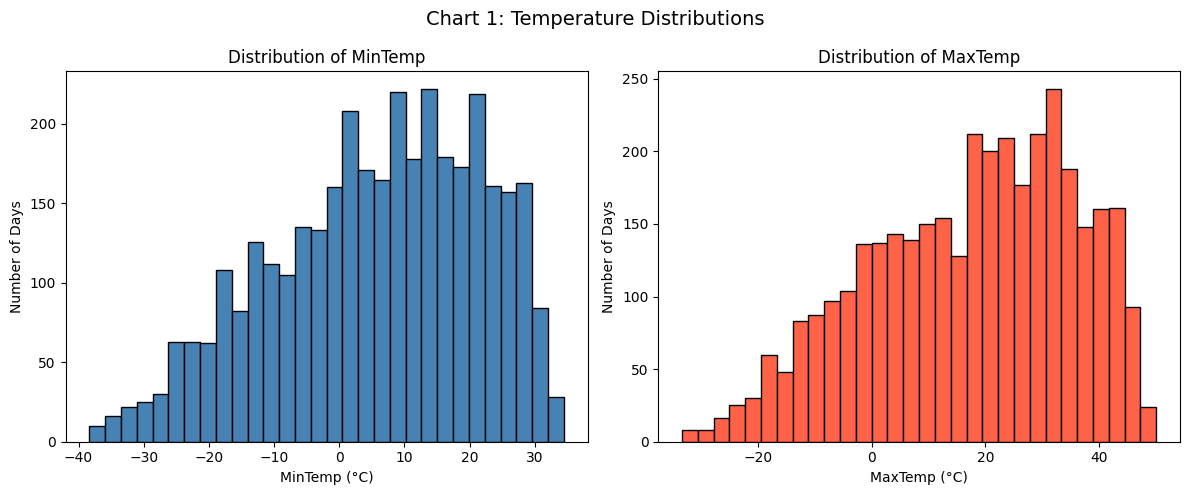

In [12]:
# ── Chart 1: Histogram of MinTemp & MaxTemp ──────────────────
# See how each temperature is distributed across all records

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MinTemp histogram
axes[0].hist(df['MinTemp'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of MinTemp')
axes[0].set_xlabel('MinTemp (°C)')
axes[0].set_ylabel('Number of Days')

# MaxTemp histogram
axes[1].hist(df['MaxTemp'], bins=30, color='tomato', edgecolor='black')
axes[1].set_title('Distribution of MaxTemp')
axes[1].set_xlabel('MaxTemp (°C)')
axes[1].set_ylabel('Number of Days')

plt.suptitle('Chart 1: Temperature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

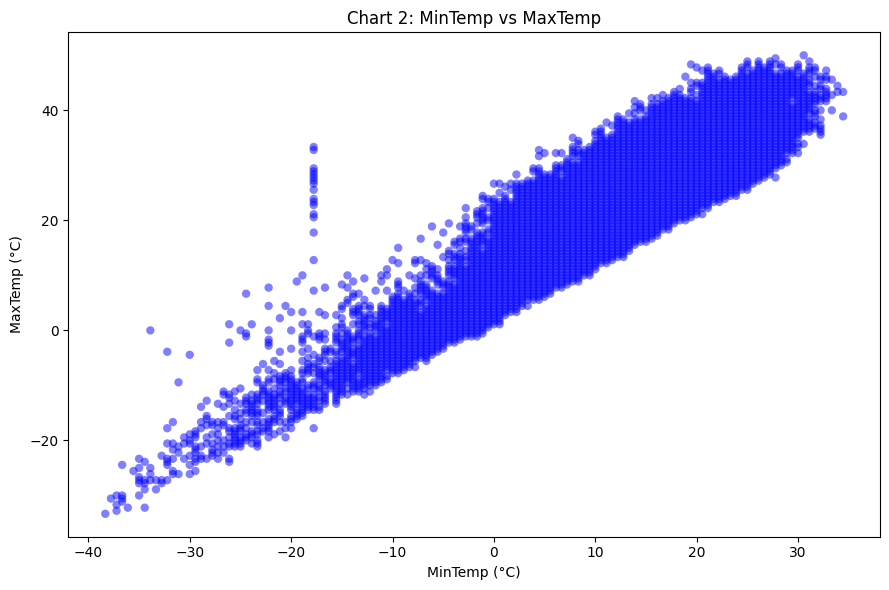

In [13]:
# ── Chart 2: Scatter Plot — MinTemp vs MaxTemp ───────────────
# Each dot = one day. Spot if there's a clear relationship.
# Color-coded by Month to see seasonal pattern


plt.figure(figsize=(9, 6))

scatter = plt.scatter(df['MinTemp'], df['MaxTemp'],
                      c='blue',
                      alpha=0.5,
                      edgecolors='none')

plt.title('Chart 2: MinTemp vs MaxTemp')
plt.xlabel('MinTemp (°C)')
plt.ylabel('MaxTemp (°C)')
plt.tight_layout()
plt.show()


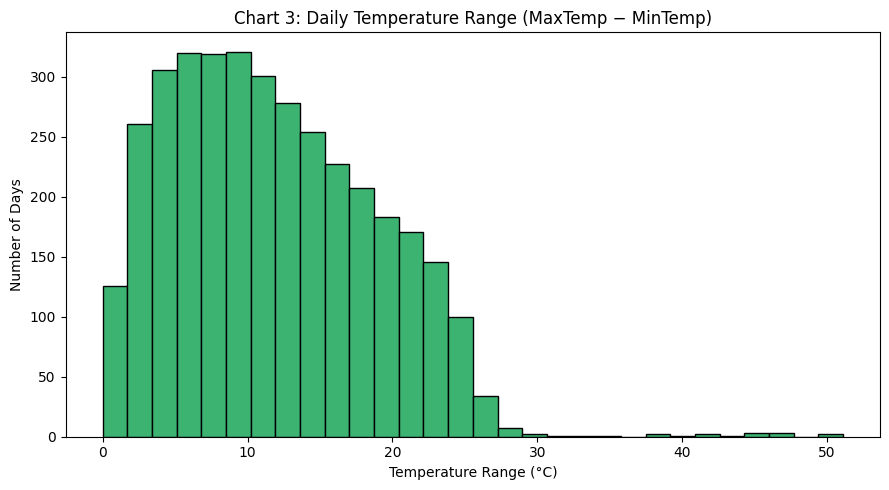

Average daily temperature range: 11.85 °C
Min range: 0.0 °C
Max range: 51.11 °C


In [14]:
# ── Chart 3: Daily Temperature Range ────────────────────────
# MaxTemp - MinTemp = how big the daily gap is
# Unique to our dataset — each day has both recorded


plt.figure(figsize=(9, 5))

plt.hist(df['MaxTemp'] - df['MinTemp'], bins=30, color='mediumseagreen', edgecolor='black')
plt.title('Chart 3: Daily Temperature Range (MaxTemp − MinTemp)')
plt.xlabel('Temperature Range (°C)')
plt.ylabel('Number of Days')
plt.tight_layout()
plt.show()

print("Average daily temperature range:", round((df['MaxTemp'] - df['MinTemp']).mean(), 2), "°C")
print("Min range:", round((df['MaxTemp'] - df['MinTemp']).min(), 2), "°C")
print("Max range:", round((df['MaxTemp'] - df['MinTemp']).max(), 2), "°C")

# Correlation Analysis

Correlation Matrix:
          MinTemp   MaxTemp
MinTemp  1.000000  0.925196
MaxTemp  0.925196  1.000000



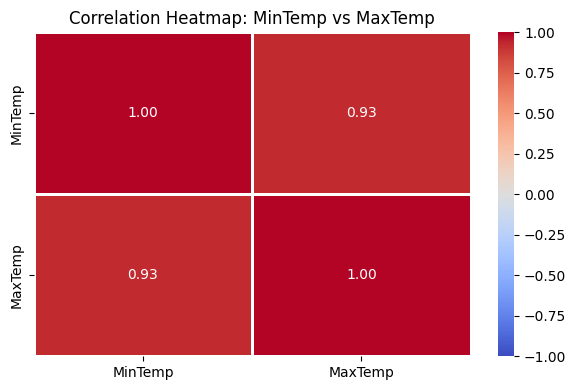

In [15]:
corr_matrix = df[['MinTemp', 'MaxTemp']].corr()

print("Correlation Matrix:")
print(corr_matrix)
print()

# ──Plot Heatmap ──────────────────────────────────────
plt.figure(figsize=(6, 4))

sns.heatmap(corr_matrix,
            annot=True,          # show numbers inside boxes
            fmt=".2f",           # round to 2 decimal places
            cmap='coolwarm',     # blue = low, red = high correlation
            vmin=-1, vmax=1,     # correlation range is always -1 to 1
            linewidths=1,        # border between boxes
            linecolor='white')

plt.title('Correlation Heatmap: MinTemp vs MaxTemp')
plt.tight_layout()
plt.show()

In [16]:
corr = df['MinTemp'].corr(df['MaxTemp'])
print(f"\nPearson Correlation: {corr:.4f}")

if corr > 0.7:
    print("→ Strong positive relationship between MinTemp and MaxTemp")
elif corr > 0.4:
    print("→ Moderate positive relationship between MinTemp and MaxTemp")
else:
    print("→ Weak relationship between MinTemp and MaxTemp")


Pearson Correlation: 0.9252
→ Strong positive relationship between MinTemp and MaxTemp


# Split the Data

In [17]:
# Prepare Features & Target
X = df[['MinTemp']].values   
y = df['MaxTemp'].values

In [18]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')


Train size: 2864, Test size: 716


# Building Models

## Linear Regression Model

In [19]:
# Train Linear Regression Model
model1 = LinearRegression()
model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
print("--- Model 1: Linear Regression ---")
print("Slope (b)    :", round(model1.coef_[0], 4))
print("Intercept (a):", round(model1.intercept_, 4))
print(f"Equation: MaxTemp = {round(model1.intercept_,2)} + {round(model1.coef_[0],2)} x MinTemp")
print()

--- Model 1: Linear Regression ---
Slope (b)    : 1.044
Intercept (a): 11.6187
Equation: MaxTemp = 11.62 + 1.04 x MinTemp



### Predictions

In [21]:
# ── Make Predictions ──────────────────────────────────
pred1 = model1.predict(X_test)   

# ── See Actual vs Predicted ──────────────────────────
results = pd.DataFrame({
    'Actual MaxTemp'   : y_test,
    'Predicted MaxTemp': pred1.round(2)
})

print("Actual vs Predicted (first 10 rows):")
print(results.head(10))

Actual vs Predicted (first 10 rows):
   Actual MaxTemp  Predicted MaxTemp
0       12.777778              18.58
1       25.555556              26.70
2       29.444444              22.64
3       37.777778              27.28
4       45.555556              34.24
5       25.000000              30.76
6       33.333333              24.96
7       44.444444              34.82
8       44.444444              41.78
9       34.444444              33.08


## Random Forest Regressor Model

In [22]:
model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)          # learn from training data

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Predictions

In [23]:
pred2 = model2.predict(X_test)        # predict on test data

results = pd.DataFrame({
    'Actual MaxTemp'      : y_test,
    'Predicted MaxTemp': pred2.round(2)
})

print("Sample Predictions (first 10 rows):")
print(results.head(10))

Sample Predictions (first 10 rows):
   Actual MaxTemp  Predicted MaxTemp
0       12.777778              20.50
1       25.555556              29.96
2       29.444444              23.57
3       37.777778              27.09
4       45.555556              35.90
5       25.000000              31.90
6       33.333333              24.15
7       44.444444              35.42
8       44.444444              39.95
9       34.444444              33.09


# Compare 2 models Predictions

In [24]:
results = pd.DataFrame({
    'Actual MaxTemp'      : y_test,
    'Model1 (Linear)'     : pred1.round(2),
    'Model2 (RandomForest)': pred2.round(2)
})

print("Sample Predictions (first 10 rows):")
print(results.head(10))

Sample Predictions (first 10 rows):
   Actual MaxTemp  Model1 (Linear)  Model2 (RandomForest)
0       12.777778            18.58                  20.50
1       25.555556            26.70                  29.96
2       29.444444            22.64                  23.57
3       37.777778            27.28                  27.09
4       45.555556            34.24                  35.90
5       25.000000            30.76                  31.90
6       33.333333            24.96                  24.15
7       44.444444            34.82                  35.42
8       44.444444            41.78                  39.95
9       34.444444            33.08                  33.09


# Models Evaluation

In [25]:
# ── Calculate Metrics for Each Model ─────────────────────────

# Model 1 — Linear Regression
r2_1   = r2_score(y_test, pred1)
mae_1  = mean_absolute_error(y_test, pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test, pred1))

# Model 2 — Random Forest
r2_2   = r2_score(y_test, pred2)
mae_2  = mean_absolute_error(y_test, pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, pred2))


In [26]:
# ── Print Results as a Clear Table ───────────────────────────
results = pd.DataFrame({
    'Model' : ['Linear Regression', 'Random Forest'],
    'R²'    : [round(r2_1,4),   round(r2_2,4)],
    'MAE'   : [round(mae_1,4),  round(mae_2,4)],
    'RMSE'  : [round(rmse_1,4), round(rmse_2,4)]
})

print("=== Model Evaluation Results ===")
print(results.to_string(index=False))
print()


# ── Print the Winner for Each Metric ─────────────────────────
print("Best R²  (highest) →", results.loc[results['R²'].idxmax(),   'Model'])
print("Best MAE (lowest)  →", results.loc[results['MAE'].idxmin(),  'Model'])
print("Best RMSE(lowest)  →", results.loc[results['RMSE'].idxmin(), 'Model'])

=== Model Evaluation Results ===
            Model     R²    MAE   RMSE
Linear Regression 0.8499 5.7483 6.9901
    Random Forest 0.8459 5.9089 7.0822

Best R²  (highest) → Linear Regression
Best MAE (lowest)  → Linear Regression
Best RMSE(lowest)  → Linear Regression


# Visualization

In [27]:
# ── Shared setup for smooth curve lines ──────────────────────
X_line = np.linspace(df['MinTemp'].min(), df['MinTemp'].max(), 300).reshape(-1, 1)
pred_line1 = model1.predict(X_line)
pred_line2 = model2.predict(X_line)

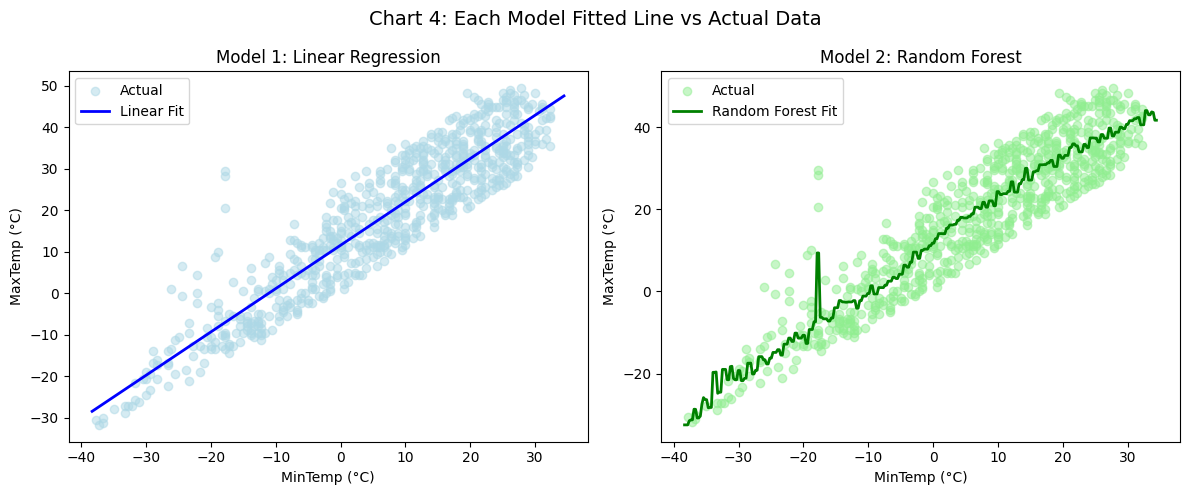

In [28]:
# Each Model's Line on Separate Scatter Plots

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Model 1: Linear Regression ───────────────────────────────
axes[0].scatter(X_test, y_test, color='lightblue', alpha=0.5, label='Actual')
axes[0].plot(X_line, pred_line1, color='blue', linewidth=2, label='Linear Fit')
axes[0].set_title('Model 1: Linear Regression')
axes[0].set_xlabel('MinTemp (°C)')
axes[0].set_ylabel('MaxTemp (°C)')
axes[0].legend()

# ── Model 2: Random Forest ────────────────────────────────────
axes[1].scatter(X_test, y_test, color='lightgreen', alpha=0.5, label='Actual')
axes[1].plot(X_line, pred_line2, color='green', linewidth=2, label='Random Forest Fit')
axes[1].set_title('Model 2: Random Forest')
axes[1].set_xlabel('MinTemp (°C)')
axes[1].set_ylabel('MaxTemp (°C)')
axes[1].legend()

plt.suptitle('Chart 4: Each Model Fitted Line vs Actual Data', fontsize=14)
plt.tight_layout()
plt.show()

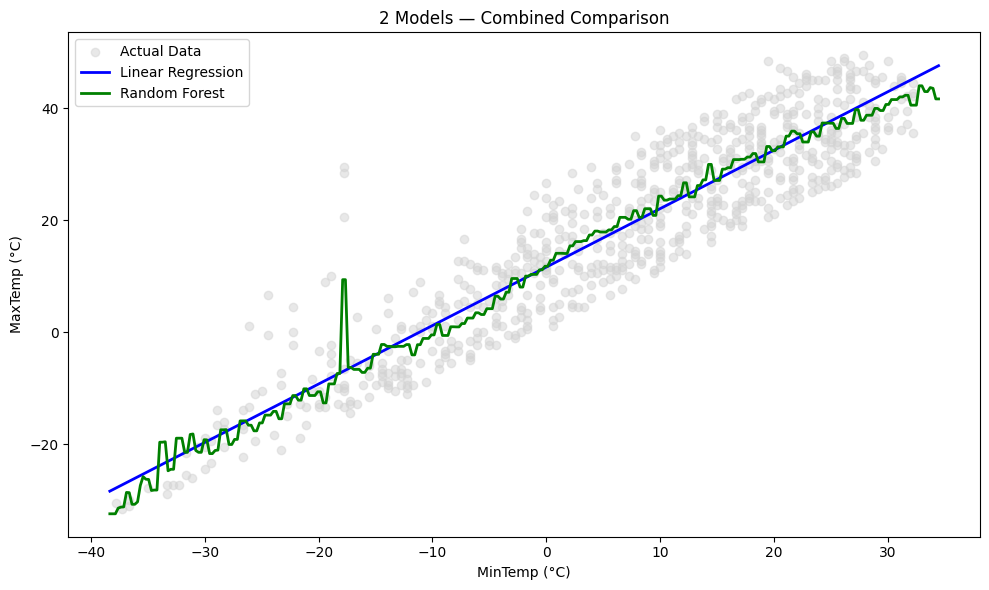

In [29]:
#  All 3 Model Lines on ONE Scatter Plot

plt.figure(figsize=(10, 6))

plt.scatter(X_test, y_test, color='lightgray', alpha=0.5, label='Actual Data')
plt.plot(X_line, pred_line1, color='blue',   linewidth=2, label='Linear Regression')
plt.plot(X_line, pred_line2, color='green',  linewidth=2, label='Random Forest')

plt.title('2 Models — Combined Comparison')
plt.xlabel('MinTemp (°C)')
plt.ylabel('MaxTemp (°C)')
plt.legend()
plt.tight_layout()
plt.show()

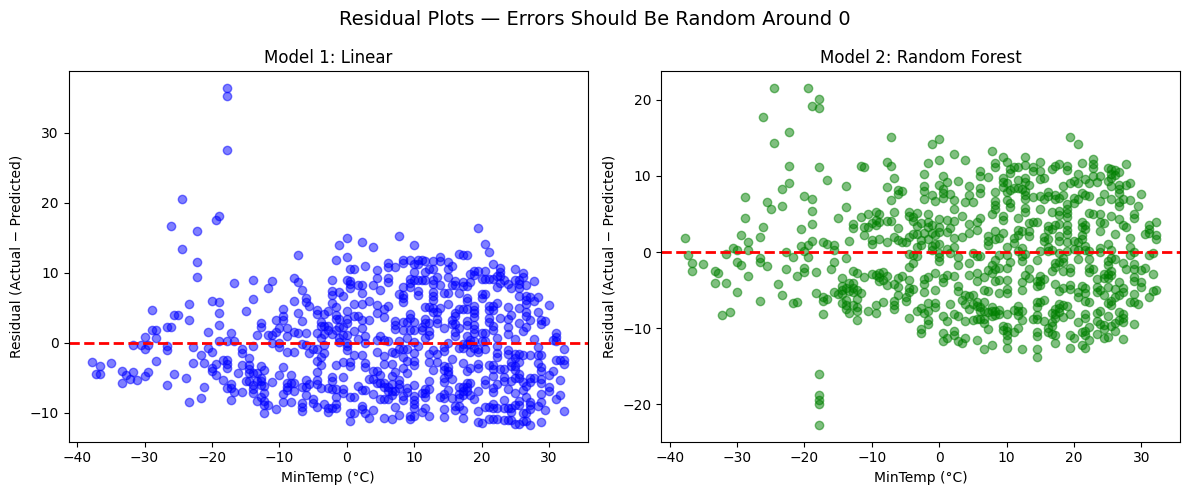

In [30]:
#  Residual Plot (Actual − Predicted)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

residuals = [
    ('Model 1: Linear',        y_test - pred1, 'blue'),
    ('Model 2: Random Forest', y_test - pred2, 'green')
]

for ax, (title, resid, color) in zip(axes, residuals):
    ax.scatter(X_test, resid, color=color, alpha=0.5)
    ax.axhline(y=0, color='red', linewidth=2, linestyle='--')  # zero error line
    ax.set_title(title)
    ax.set_xlabel('MinTemp (°C)')
    ax.set_ylabel('Residual (Actual − Predicted)')

plt.suptitle('Residual Plots — Errors Should Be Random Around 0', fontsize=14)
plt.tight_layout()
plt.show()

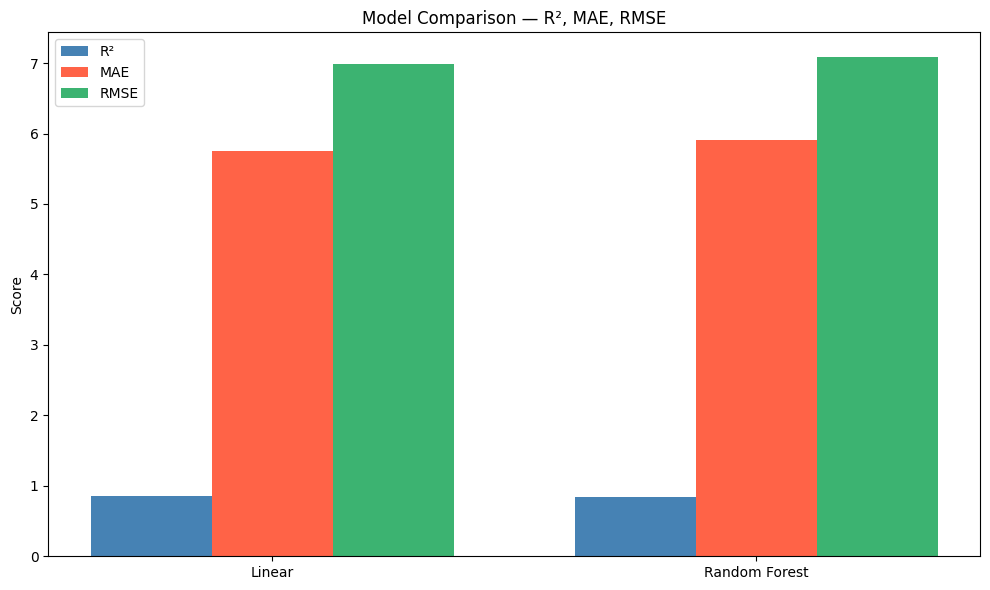

In [31]:
#  Bar Chart Comparing R², MAE, RMSE

models     = ['Linear', 'Random Forest']
r2_scores  = [r2_1,   r2_2]
mae_scores = [mae_1,  mae_2]
rmse_scores= [rmse_1, rmse_2]

x     = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - width, r2_scores,   width, label='R²',   color='steelblue')
ax.bar(x,         mae_scores,  width, label='MAE',  color='tomato')
ax.bar(x + width, rmse_scores, width, label='RMSE', color='mediumseagreen')

ax.set_title('Model Comparison — R², MAE, RMSE')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

# Model Comparison & Selection

In [32]:
# ── Step 1: Comparison Table ──────────────────────────────────
comparison = pd.DataFrame({
    'Model' : ['Linear Regression', 'Random Forest'],
    'R²'    : [round(r2_1, 4),   round(r2_2, 4)],
    'MAE'   : [round(mae_1, 4),  round(mae_2, 4)],
    'RMSE'  : [round(rmse_1, 4), round(rmse_2, 4)]
})

print("MODEL COMPARISON")
print(comparison.to_string(index=False))
print()


# ── Step 2: Winner Per Metric ─────────────────────────────────
print("Best R²   (highest) →", comparison.loc[comparison['R²'].idxmax(),  'Model'])
print("Best MAE  (lowest)  →", comparison.loc[comparison['MAE'].idxmin(),  'Model'])
print("Best RMSE (lowest)  →", comparison.loc[comparison['RMSE'].idxmin(), 'Model'])
print()


# ── Step 3: Is Random Forest Worth It? ───────────────────────
r2_improvement = round(r2_2 - r2_1, 4)

print("R² Improvement (Random Forest over Linear):", r2_improvement)
print()

if r2_improvement < 0.02:
    print("Verdict: Improvement is MARGINAL")
    print("Recommended → Linear Regression  (simpler & equally good)")
else:
    print("Verdict: Improvement is SIGNIFICANT")
    print("Recommended → Random Forest  (better predictions)")
print()


# ── Step 4: Final Equation & Example ─────────────────────────
print("Linear Regression Equation:")
print(f"MaxTemp = {round(model1.intercept_, 2)} + {round(model1.coef_[0], 2)} x MinTemp")
print()

example_min = 22.22
example_max = round(model1.intercept_ + model1.coef_[0] * example_min, 2)
print(f"Example: If MinTemp = {example_min}°C  →  Predicted MaxTemp = {example_max}°C")

MODEL COMPARISON
            Model     R²    MAE   RMSE
Linear Regression 0.8499 5.7483 6.9901
    Random Forest 0.8459 5.9089 7.0822

Best R²   (highest) → Linear Regression
Best MAE  (lowest)  → Linear Regression
Best RMSE (lowest)  → Linear Regression

R² Improvement (Random Forest over Linear): -0.004

Verdict: Improvement is MARGINAL
Recommended → Linear Regression  (simpler & equally good)

Linear Regression Equation:
MaxTemp = 11.62 + 1.04 x MinTemp

Example: If MinTemp = 22.22°C  →  Predicted MaxTemp = 34.82°C


# Conclusion

In [33]:
# ── Question 1: Is there a relationship? ─────────────────────
correlation = df['MinTemp'].corr(df['MaxTemp'])

print("QUESTION 1: Is there a relationship between")
print("            MinTemp and MaxTemp?")
print()
print(f"Correlation Value: {round(correlation, 4)}")
print()

if correlation >= 0.85:
    print("Answer: YES — Very Strong Positive Relationship")
    print("When MinTemp is high, MaxTemp tends to be high too.")
elif correlation >= 0.50:
    print("Answer: YES — Moderate Positive Relationship")
else:
    print("Answer: WEAK — Not a strong relationship")
print()

QUESTION 1: Is there a relationship between
            MinTemp and MaxTemp?

Correlation Value: 0.9252

Answer: YES — Very Strong Positive Relationship
When MinTemp is high, MaxTemp tends to be high too.



In [34]:
# ── Question 2: Can we predict MaxTemp from MinTemp? ─────────
print("QUESTION 2: Can we predict MaxTemp given MinTemp?")
print()

print(f"Linear Regression  →  R²: {round(r2_1,4)}  "
      f"MAE: {round(mae_1,4)}  RMSE: {round(rmse_1,4)}")
print(f"Random Forest      →  R²: {round(r2_2,4)}  "
      f"MAE: {round(mae_2,4)}  RMSE: {round(rmse_2,4)}")
print()

if r2_2 - r2_1 < 0.02:
    best_model = "Linear Regression"
    best_r2    = r2_1
    best_mae   = mae_1
else:
    best_model = "Random Forest"
    best_r2    = r2_2
    best_mae   = mae_2

print(f"Answer: YES — Best Model is {best_model}")
print(f"        R² = {round(best_r2, 4)} "
      f"(explains {round(best_r2*100, 2)}% of MaxTemp variation)")
print(f"        MAE = {round(best_mae, 4)}°C average prediction error")
print()

QUESTION 2: Can we predict MaxTemp given MinTemp?

Linear Regression  →  R²: 0.8499  MAE: 5.7483  RMSE: 6.9901
Random Forest      →  R²: 0.8459  MAE: 5.9089  RMSE: 7.0822

Answer: YES — Best Model is Linear Regression
        R² = 0.8499 (explains 84.99% of MaxTemp variation)
        MAE = 5.7483°C average prediction error

